In [ ]:
# Name: DVN Surya Kiran
# Roll No: CH.SC.U4CSE24116
# Lab 11 Exercise 1 - PCA Real Estate Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
data = {
    'Price':        [500000, 750000, 300000, 900000, 450000, 650000, 820000, 380000, 710000, 550000],
    'Size':         [1200, 1800, 900, 2200, 1100, 1600, 2000, 950, 1750, 1300],
    'Age':          [10, 25, 5, 30, 15, 20, 28, 8, 22, 12],
    'Bedrooms':     [3, 4, 2, 5, 3, 4, 4, 2, 4, 3],
    'Distance':     [5, 15, 3, 20, 8, 12, 18, 4, 14, 7],
    'Crime_Rate':   [2, 8, 1, 10, 3, 6, 9, 2, 7, 4],
    'School_Score': [8, 5, 9, 4, 7, 6, 5, 9, 6, 8],
    'Sold':         [1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
}
df = pd.DataFrame(data)
print(df)

    Price  Size  Age  Bedrooms  Distance  Crime_Rate  School_Score  Sold
0  500000  1200   10         3         5           2             8     1
1  750000  1800   25         4        15           8             5     0
2  300000   900    5         2         3           1             9     1
3  900000  2200   30         5        20          10             4     0
4  450000  1100   15         3         8           3             7     1
5  650000  1600   20         4        12           6             6     0
6  820000  2000   28         4        18           9             5     0
7  380000   950    8         2         4           2             9     1
8  710000  1750   22         4        14           7             6     0
9  550000  1300   12         3         7           4             8     1


In [ ]:
print(df.isnull().sum())
print(df.shape)

Price           0
Size            0
Age             0
Bedrooms        0
Distance        0
Crime_Rate      0
School_Score    0
Sold            0
dtype: int64
(10, 8)


In [ ]:
x = df.drop('Sold', axis=1)
y = df['Sold']
sc = StandardScaler()
x_scaled = sc.fit_transform(x)
print("Scaled data shape:", x_scaled.shape)

Scaled data shape: (10, 7)


In [ ]:
pca = PCA()
pca.fit(x_scaled)
explained = pca.explained_variance_ratio_
print("Explained variance ratio:", explained)
print("Cumulative variance:", np.cumsum(explained))

Explained variance ratio: [9.74928042e-01 1.20735248e-02 9.93375490e-03 1.40984479e-03
 8.86935868e-04 7.07985409e-04 5.99120984e-05]
Cumulative variance: [0.97492804 0.98700157 0.99693532 0.99834517 0.9992321  0.99994009
 1.        ]


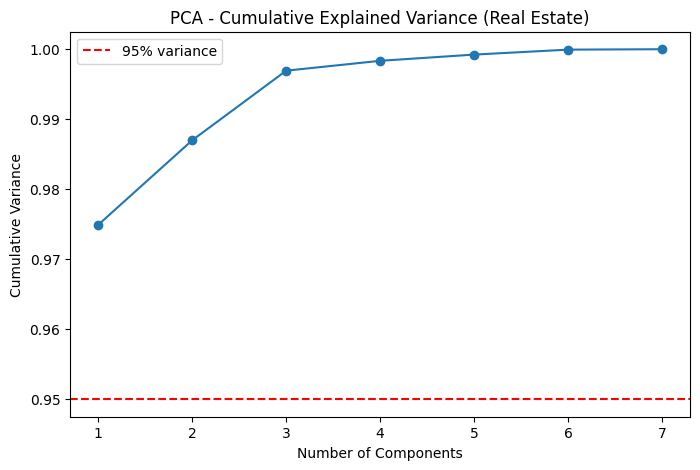

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained)+1), np.cumsum(explained), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.title('PCA - Cumulative Explained Variance (Real Estate)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.show()

In [ ]:
pca2 = PCA(n_components=2)
x_pca = pca2.fit_transform(x_scaled)
print("Reduced shape:", x_pca.shape)
print("Variance explained by 2 components:", sum(pca2.explained_variance_ratio_))

Reduced shape: (10, 2)
Variance explained by 2 components: 0.9870015669313746


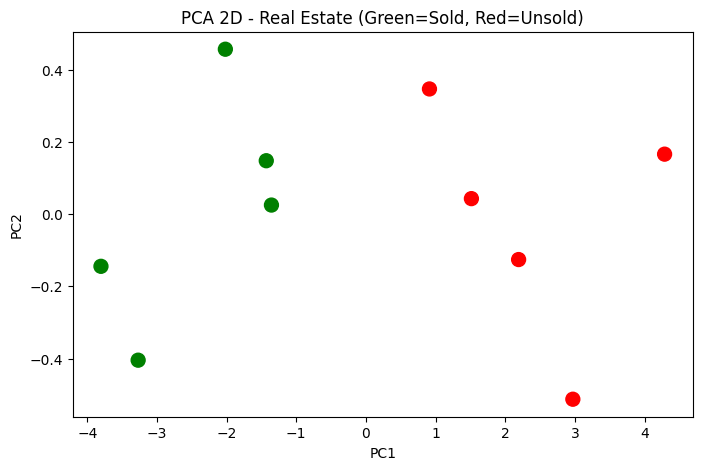

In [ ]:
plt.figure(figsize=(8, 5))
colors = ['green' if s==1 else 'red' for s in y]
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=colors, s=100)
plt.title('PCA 2D - Real Estate (Green=Sold, Red=Unsold)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'PC1_Loading': abs(pca2.components_[0])
}).sort_values('PC1_Loading', ascending=False)
print(feature_importance)

        Feature  PC1_Loading
4      Distance     0.380315
2           Age     0.379826
1          Size     0.379500
5    Crime_Rate     0.378978
0         Price     0.378520
6  School_Score     0.377036
3      Bedrooms     0.371503


In [ ]:
print("Insights for Maggie:")
print("Properties not sold likely have:")
print("- Higher crime rate")
print("- Greater distance from city center")
print("- Older age")
print("- Lower school scores")
print("PCA helps identify these key factors driving unsold properties.")

Insights for Maggie:
Properties not sold likely have:
- Higher crime rate
- Greater distance from city center
- Older age
- Lower school scores
PCA helps identify these key factors driving unsold properties.
